# 公式 o6 — Action Potentials in Neurons（Hodgkin-Huxley）

> **出典（E-Cell4 公式）**: Examples / example06 — https://ecell4.e-cell.org/examples/example06.html （Hodgkin-Huxley 1952）
>
> 公式コードをそのまま移植（描画のみ matplotlib）。神経膜の活動電位を、ゲート変数 m/h/n と
> 膜電位 Vm の連立 ODE で表す——反応シミュレータを電気生理モデルに使う例。

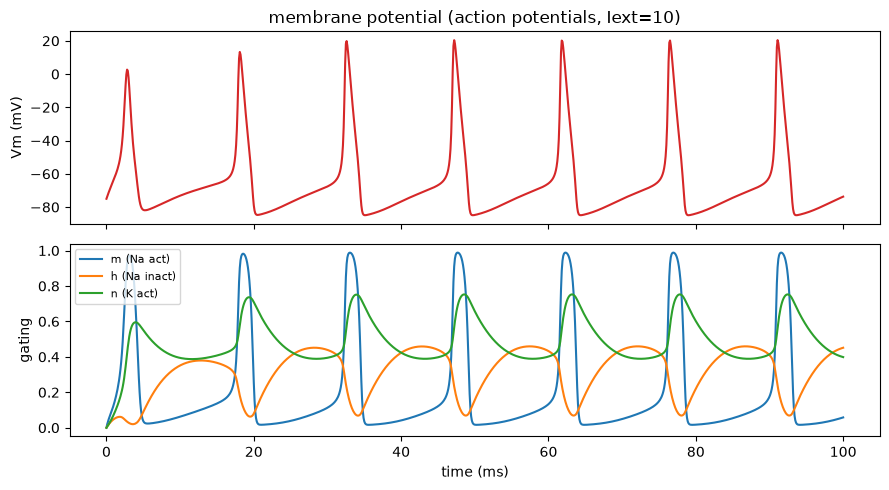

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

Q10=3.0; GNa=120.0; GK=36.0; gL=0.3; EL=-64.387; ENa=40.0; EK=-87.0; Cm=1.0; T=6.3; Iext=10.0
with reaction_rules():
    Q = Q10 ** ((T - 6.3) / 10)
    alpha_m = -0.1 * (Vm + 50) / (exp(-(Vm + 50) / 10) - 1)
    beta_m = 4 * exp(-(Vm + 75) / 18)
    ~m > m | Q * (alpha_m * (1 - m) - beta_m * m)
    alpha_h = 0.07 * exp(-(Vm + 75) / 20)
    beta_h = 1.0 / (exp(-(Vm + 45) / 10) + 1)
    ~h > h | Q * (alpha_h * (1 - h) - beta_h * h)
    alpha_n = -0.01 * (Vm + 65) / (exp(-(Vm + 65) / 10) - 1)
    beta_n = 0.125 * exp(-(Vm + 75) / 80)
    ~n > n | Q * (alpha_n * (1 - n) - beta_n * n)
    gNa = (m ** 3) * h * GNa; INa = gNa * (Vm - ENa)
    gK = (n ** 4) * GK; IK = gK * (Vm - EK)
    IL = gL * (Vm - EL)
    ~Vm > Vm | (Iext - (IL + INa + IK)) / Cm
hhm = get_model()
a = run_simulation(100, ndiv=1000, model=hhm, y0={'Vm': -75}, species_list=['Vm','m','h','n']).as_array()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(a[:,0], a[:,1], 'C3'); ax1.set_ylabel('Vm (mV)'); ax1.set_title('membrane potential (action potentials, Iext=10)')
for i, lab in enumerate(['m (Na act)','h (Na inact)','n (K act)'], 2):
    ax2.plot(a[:,0], a[:,i], label=lab)
ax2.set_xlabel('time (ms)'); ax2.set_ylabel('gating'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 読み取り

一定の外部電流 `Iext=10` で膜が周期的に**スパイク（活動電位）**を発火する。Na⁺ チャネルの活性化 m・不活性化 h、
K⁺ チャネルの活性化 n が協調して、脱分極→再分極を繰り返す。ノーベル賞の Hodgkin-Huxley モデルを rate-law ODE で実装した例。